In [ ]:
import sys as _sys
from pathlib import Path as _Path
try:
    _sys.path.insert(0, str(_Path(__vsc_ipynb_file__).parent.parent))
except NameError:
    pass  # Not in VS Code; rely on pip install -e .

import os
from scripts.utils import setup_notebook, OKABE_ITO_CYCLE

PROJECT_ROOT, np, pd, plt, Path = setup_notebook()

from scripts.data_loader import AHE_hysteresis
from scripts.ahe_collection import AHE_Collection

color_values = OKABE_ITO_CYCLE
Save = True

In [ ]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "Sample06042025" / "ZFC"
PLOTS_DIR    = PROJECT_ROOT / "figures"
RESULTS_DIR  = PROJECT_ROOT / "results"
PLOTS_DIR.mkdir(exist_ok=True)

print(f"Raw data folder: {RAW_DATA_DIR}")
print(f"Figures folder: {PLOTS_DIR}")

folder = RAW_DATA_DIR

In [3]:
custom_keys = {
    "ZFC__20250407_0330__10K.h5": "ZFC",
    "ZFC_PF_2500mT_20250407_1858__10K.h5": "PF 2.5 T",
    "ZFC_PF_M2500mT_20250407_1549__10K.h5": "PF -2.5 T"
}
EB_S3 = AHE_Collection(RAW_DATA_DIR, custom_keys)

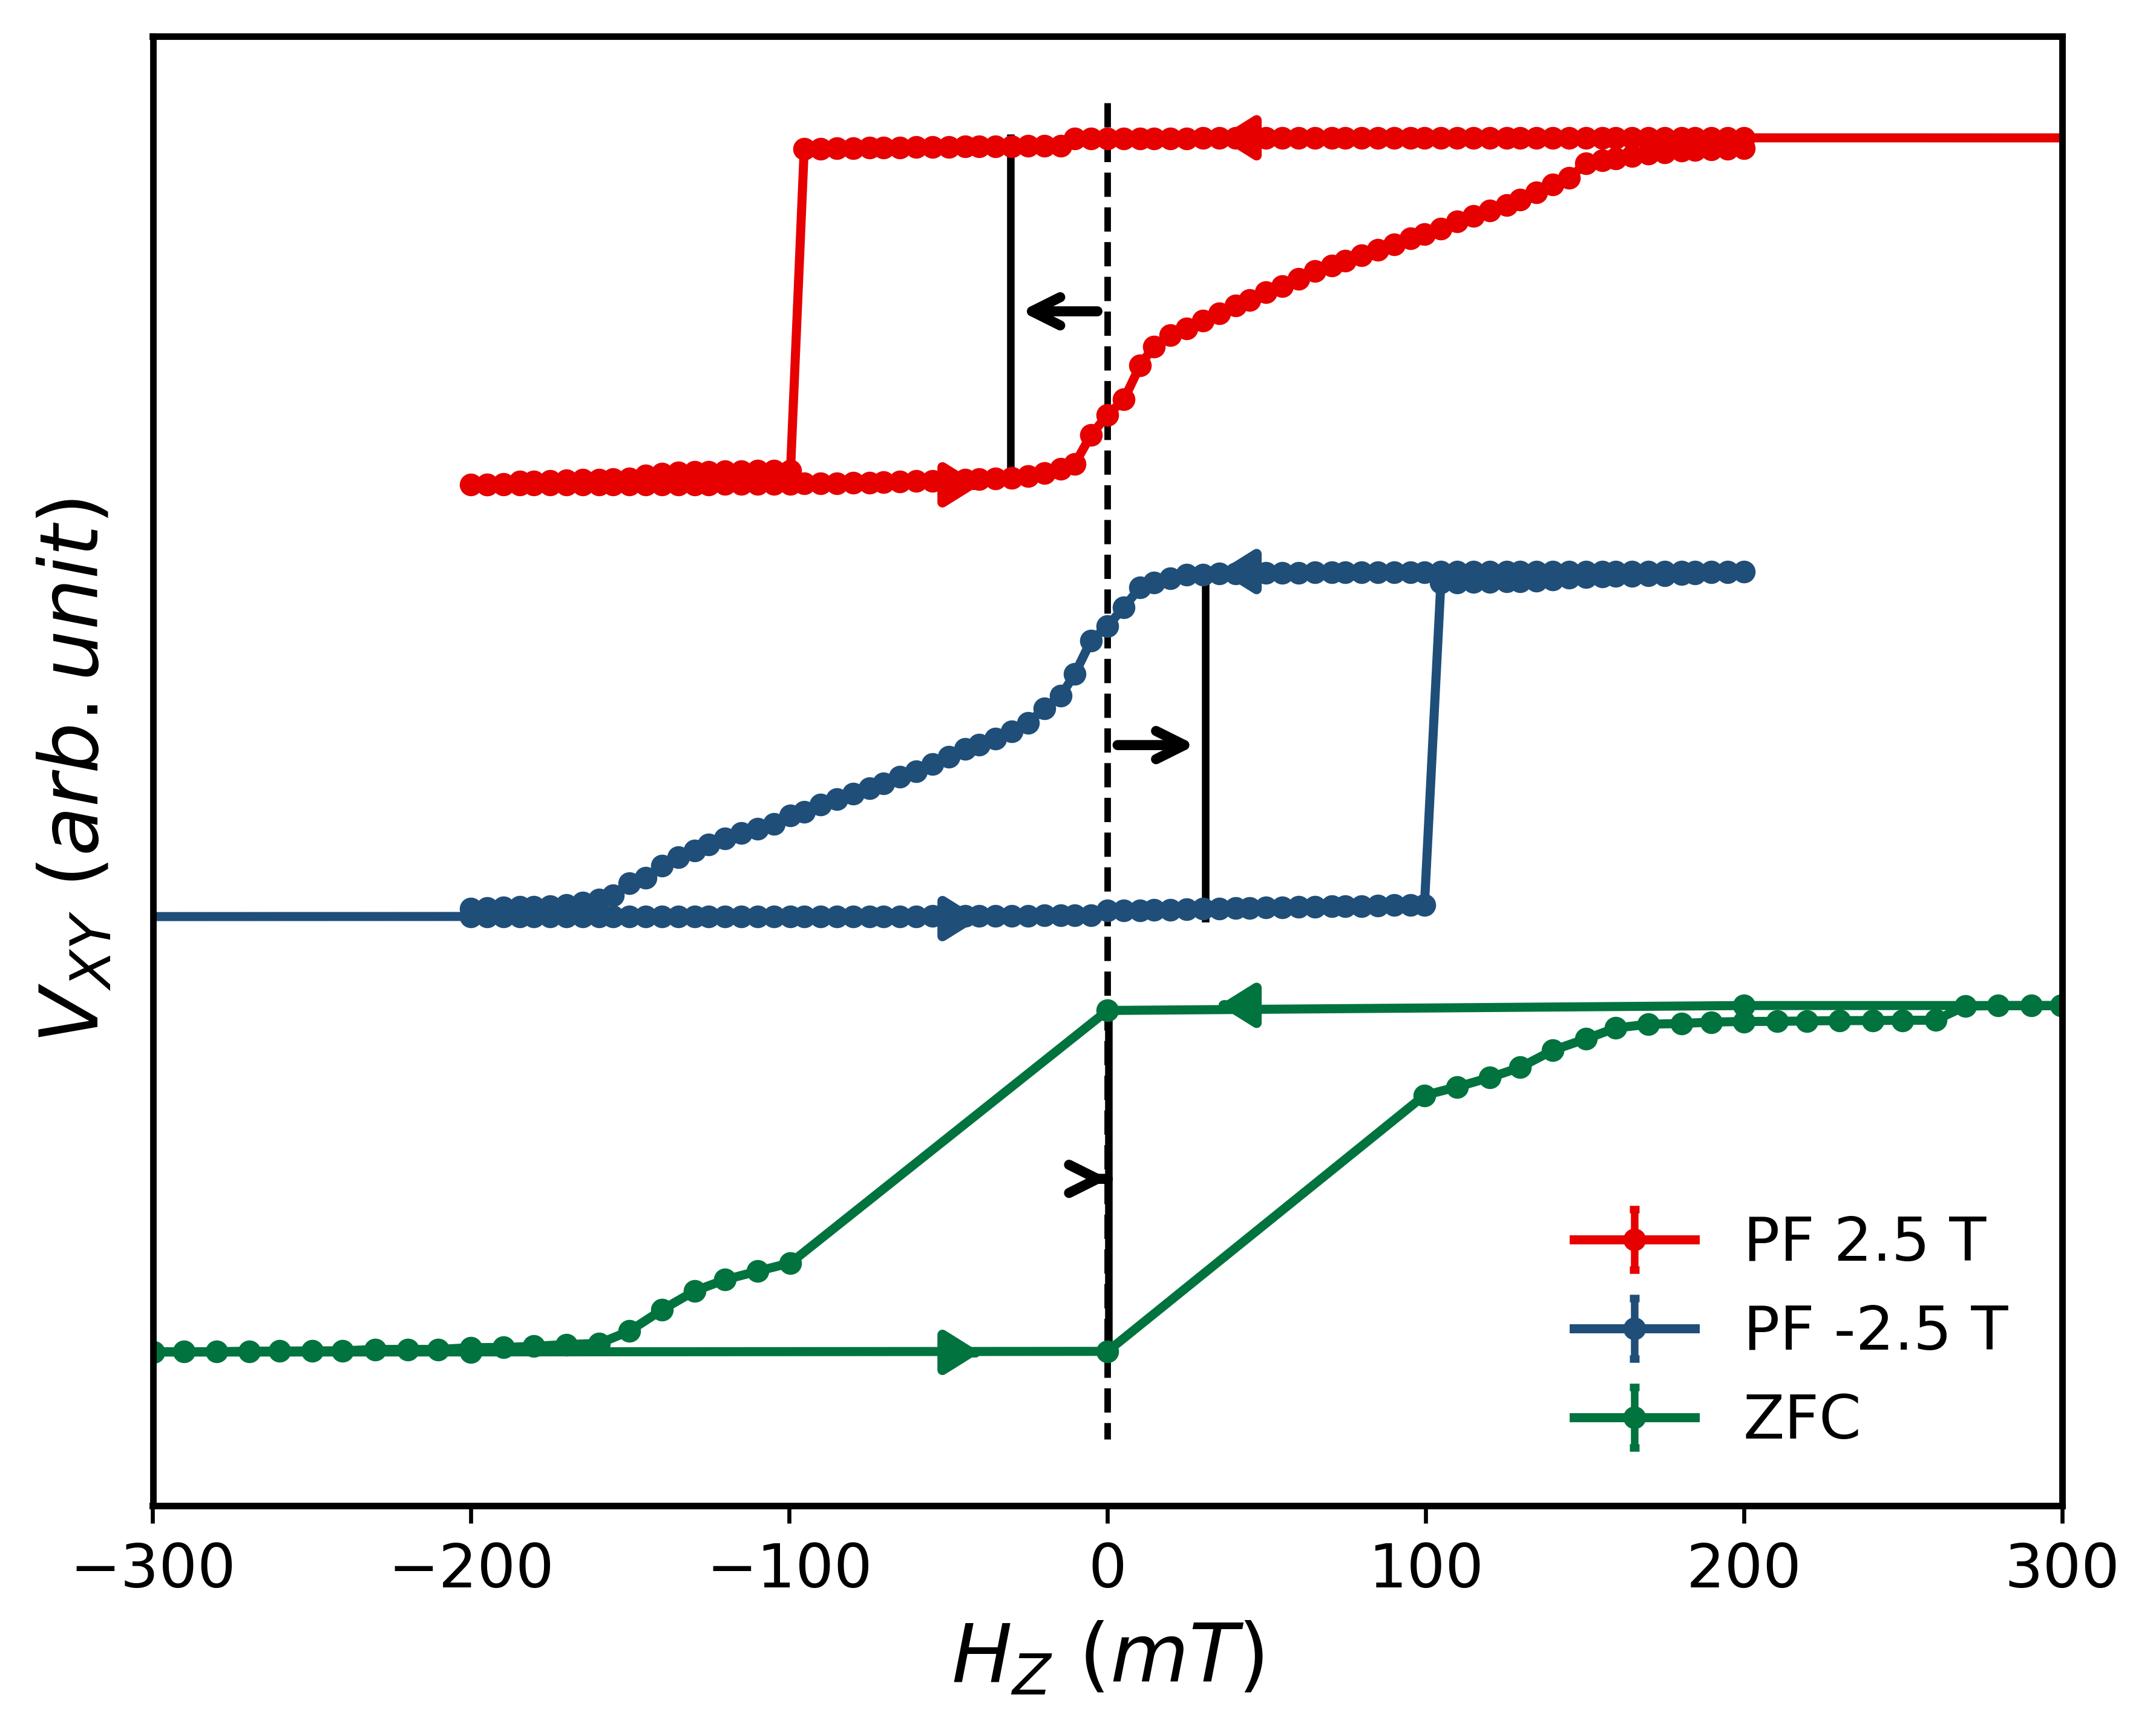

In [4]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=600)
n=3

for i, (key, obj) in enumerate(EB_S3.measurements.items()):
    vspacing = 2.5
    if i<n:
        color = color_values[i % len(color_values)]
        ax.errorbar(obj.field, obj.vxy_norm - vspacing*i, obj.vxy_err/obj.vahe, fmt='-o',
        color=color,
        label=key,
        capsize=1, markersize = 3,
        elinewidth=1.5,
        markeredgewidth=1.5)

        ax.plot(
        [obj.heb, obj.heb],   # vertical line at coercivity
        np.array([1, -1]) - i * vspacing,
        color='k',
        linestyle='-',
        linewidth=1.5
    )

        arrow_loop_down = 1 - i * vspacing  # Y-position for the arrow (slightly above center line)

        ax.annotate(
            '',  # No text
            xy=(35, arrow_loop_down),   # arrow head
            xytext=(40, arrow_loop_down),      # arrow tail (starting point)
            arrowprops=dict(
                arrowstyle='-|>,head_width=0.25',
                color=color,
                linewidth=2
            )
        )

        arrow_loop_up = -1 - i * vspacing  # Y-position for the arrow (slightly above center line)

        ax.annotate(
            '',  # No text
            xy=(-40, arrow_loop_up),   # arrow head
            xytext=(-45, arrow_loop_up),      # arrow tail (starting point)
            arrowprops=dict(
                arrowstyle='-|>,head_width=0.25',
                color=color,
                linewidth=2
            )
        )

        arrow_y = 0 - i * vspacing  # Y-position for the arrow (slightly above center line)

        ax.annotate(
            '',  # No text
            xy=(obj.heb, arrow_y),   # arrow head
            xytext=(0, arrow_y),      # arrow tail (starting point)
            arrowprops=dict(
                arrowstyle='->',
                color='k',
                linewidth=2
            )
        )

# --- Vertical zero line ---
ax.plot([0, 0], [1.2, n*-vspacing + 1], color='k', linestyle='--', linewidth=1.3)

ax.set_xlabel("$H_Z$ $(mT)$")
ax.set_ylabel("$V_{XY}$ $(arb. unit)$")
ax.set_yticks([])  # Remove y-axis ticks for clean stacking
ax.legend(loc='lower right',  frameon=False)
plt.tight_layout()
plt.xlim(-300,300)




plt.savefig(os.path.join(PLOTS_DIR,"ZFC_10K_S3"))
plt.show()